# Part 1: Fit a Neural Field to a 2D Image

This notebook implements the full pipeline required in the prompt:

- MLP neural field with **sinusoidal positional encoding (PE)**
- Random pixel sampling dataloader per training iteration
- MSE loss, Adam optimizer, and PSNR metric
- Training progression visualizations
- 2x2 hyperparameter comparison grid for PE frequency `L` and MLP width
- PSNR curve for one selected run

The starting image is loaded from `images/input/part1/img_1.jpg`.

In [8]:
import copy
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

In [9]:
# Reproducibility + device setup
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Paths
IMAGE_PATH = Path("images/input/part1/img_1.jpg")
OUTPUT_DIR = Path("images/output/part1_neural_field")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert IMAGE_PATH.exists(), f"Image not found at {IMAGE_PATH}"

Using device: cpu


Loaded image: images\input\part1\img_1.jpg
Shape: H=689, W=1024, C=3


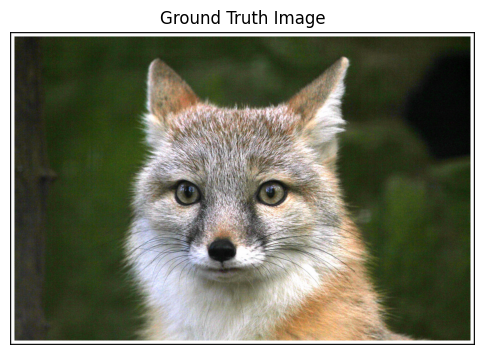

In [10]:
# Load image as float32 in [0, 1]
img_np = np.array(Image.open(IMAGE_PATH).convert("RGB"), dtype=np.float32) / 255.0
H, W, C = img_np.shape
print(f"Loaded image: {IMAGE_PATH}")
print(f"Shape: H={H}, W={W}, C={C}")

# Torch tensors for training
img_t = torch.from_numpy(img_np).to(DEVICE)
flat_rgb = img_t.view(-1, 3)

# Full coordinate grid normalized to [0, 1]
ys = torch.linspace(0.0, 1.0, H, device=DEVICE)
xs = torch.linspace(0.0, 1.0, W, device=DEVICE)
grid_y, grid_x = torch.meshgrid(ys, xs, indexing="ij")
flat_coords = torch.stack([grid_x, grid_y], dim=-1).view(-1, 2)

plt.figure(figsize=(6, 6))
plt.imshow(img_np)
plt.title("Ground Truth Image")
plt.axis("off")
plt.show()

In [11]:
def positional_encoding(xy: torch.Tensor, L: int) -> torch.Tensor:
    """
    xy: [N, 2] normalized coordinates in [0, 1]
    returns: [N, 2 + 4L] with original xy included
    """
    feats = [xy]
    for i in range(L):
        freq = (2.0 ** i) * math.pi
        feats.append(torch.sin(freq * xy))
        feats.append(torch.cos(freq * xy))
    return torch.cat(feats, dim=-1)


class NeuralFieldMLP(nn.Module):
    def __init__(self, L: int = 10, width: int = 256, hidden_layers: int = 4):
        super().__init__()
        self.L = L
        in_dim = 2 + 4 * L

        layers = []
        layers.append(nn.Linear(in_dim, width))
        layers.append(nn.ReLU(inplace=True))

        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(width, width))
            layers.append(nn.ReLU(inplace=True))

        layers.append(nn.Linear(width, 3))
        self.net = nn.Sequential(*layers)

    def forward(self, xy: torch.Tensor) -> torch.Tensor:
        pe = positional_encoding(xy, self.L)
        return torch.sigmoid(self.net(pe))


def sample_random_pixels(batch_size: int) -> tuple[torch.Tensor, torch.Tensor]:
    idx = torch.randint(0, flat_coords.shape[0], (batch_size,), device=DEVICE)
    return flat_coords[idx], flat_rgb[idx]


def mse_to_psnr(mse: torch.Tensor) -> torch.Tensor:
    return -10.0 * torch.log10(torch.clamp(mse, min=1e-10))

In [18]:
@torch.no_grad()
def render_image(model: nn.Module, h: int, w: int, chunk: int = 65536) -> np.ndarray:
    model.eval()
    preds = []
    n = flat_coords.shape[0]
    for i in range(0, n, chunk):
        coords_chunk = flat_coords[i : i + chunk]
        preds.append(model(coords_chunk))
    out = torch.cat(preds, dim=0).view(h, w, 3)
    return out.clamp(0.0, 1.0).detach().cpu().numpy()


def train_neural_field(
    L: int,
    width: int,
    hidden_layers: int = 4,
    lr: float = 1e-2,
    min_lr: float = 5e-4,
    steps: int = 1200,
    batch_size: int = 1024,
    checkpoint_steps: list[int] | None = None,
    eval_interval: int = 100,
    use_lr_decay: bool = True,
    use_best_checkpoint: bool = True,
    verbose: bool = True,
):
    if checkpoint_steps is None:
        checkpoint_steps = sorted(set([1, 100, 300, 600, 900, steps]))
    checkpoint_steps = [s for s in checkpoint_steps if 1 <= s <= steps]

    model = NeuralFieldMLP(L=L, width=width, hidden_layers=hidden_layers).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    scheduler = None
    if use_lr_decay and steps > 1 and min_lr < lr:
        gamma = (min_lr / lr) ** (1.0 / (steps - 1))
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

    loss_hist = []
    psnr_hist = []
    eval_steps = []
    eval_psnr = []
    checkpoint_states: dict[int, dict[str, torch.Tensor]] = {}

    best_psnr = -float("inf")
    best_step = 1
    best_state = None

    t0 = time.time()
    model.train()
    for step in range(1, steps + 1):
        coords_b, rgb_b = sample_random_pixels(batch_size)
        pred_b = model(coords_b)

        loss = F.mse_loss(pred_b, rgb_b)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        with torch.no_grad():
            psnr_val = mse_to_psnr(loss)

        loss_hist.append(float(loss.item()))
        psnr_hist.append(float(psnr_val.item()))

        if step in checkpoint_steps:
            checkpoint_states[step] = {
                k: v.detach().cpu().clone() for k, v in model.state_dict().items()
            }

        should_eval = (step == 1) or (step % eval_interval == 0) or (step == steps)
        if should_eval:
            full_img = render_image(model, H, W)
            full_mse = np.mean((full_img - img_np) ** 2)
            full_psnr = float(-10.0 * np.log10(max(full_mse, 1e-10)))
            eval_steps.append(step)
            eval_psnr.append(full_psnr)

            if full_psnr > best_psnr:
                best_psnr = full_psnr
                best_step = step
                best_state = {
                    k: v.detach().cpu().clone() for k, v in model.state_dict().items()
                }

        if verbose and (step == 1 or step % 100 == 0 or step == steps):
            lr_now = optimizer.param_groups[0]["lr"]
            print(
                f"Step {step:4d}/{steps} | "
                f"MSE: {loss.item():.6f} | "
                f"PSNR(batch): {psnr_val.item():.2f} dB | "
                f"LR: {lr_now:.6f}"
            )

    elapsed = time.time() - t0

    # Render checkpoints from saved states
    progression = {}
    for s in checkpoint_steps:
        if s in checkpoint_states:
            model.load_state_dict(checkpoint_states[s])
            progression[s] = render_image(model, H, W)

    # Restore best or last checkpoint
    if use_best_checkpoint and best_state is not None:
        model.load_state_dict(best_state)
    elif checkpoint_steps and checkpoint_steps[-1] in checkpoint_states:
        model.load_state_dict(checkpoint_states[checkpoint_steps[-1]])

    final_img = render_image(model, H, W)
    final_mse = np.mean((final_img - img_np) ** 2)
    final_psnr = float(-10.0 * np.log10(max(final_mse, 1e-10)))

    return {
        "model": model,
        "loss_hist": np.array(loss_hist),
        "psnr_hist": np.array(psnr_hist),
        "eval_steps": np.array(eval_steps),
        "eval_psnr": np.array(eval_psnr),
        "best_step": int(best_step),
        "best_psnr": float(best_psnr),
        "progression": progression,
        "final_img": final_img,
        "final_mse": float(final_mse),
        "final_psnr": final_psnr,
        "elapsed_sec": elapsed,
        "config": {
            "L": L,
            "width": width,
            "hidden_layers": hidden_layers,
            "lr": lr,
            "min_lr": min_lr,
            "steps": steps,
            "batch_size": batch_size,
            "eval_interval": eval_interval,
            "use_lr_decay": use_lr_decay,
            "use_best_checkpoint": use_best_checkpoint,
        },
    }

In [19]:
def plot_progression(result: dict, save_path: Path | None = None):
    steps = sorted(result["progression"].keys())
    ncols = len(steps) + 1

    fig, axes = plt.subplots(1, ncols, figsize=(3.2 * ncols, 3.4))

    axes[0].imshow(img_np)
    axes[0].set_title("Ground Truth")
    axes[0].axis("off")

    for i, s in enumerate(steps, start=1):
        axes[i].imshow(result["progression"][s])
        axes[i].set_title(f"Step {s}")
        axes[i].axis("off")

    fig.suptitle(
        f"Training Progression | L={result['config']['L']}, width={result['config']['width']}"
    )
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()


def plot_psnr_curve(result: dict, save_path: Path | None = None):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(result["psnr_hist"], linewidth=1.2, alpha=0.7, label="Batch PSNR")

    if "eval_steps" in result and len(result["eval_steps"]) > 0:
        x_eval = np.array(result["eval_steps"]) - 1
        ax.plot(
            x_eval,
            result["eval_psnr"],
            linewidth=2.2,
            marker="o",
            markersize=3,
            label="Full-image PSNR",
        )

    ax.set_title(
        f"PSNR Curve | L={result['config']['L']}, width={result['config']['width']}"
    )
    ax.set_xlabel("Iteration")
    ax.set_ylabel("PSNR (dB)")
    ax.grid(alpha=0.25)
    ax.legend()

    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()


def show_architecture(result: dict):
    cfg = result["config"]
    print("Model Architecture")
    print("------------------")
    print(f"Positional encoding L: {cfg['L']}")
    print(f"Input dim after PE: {2 + 4 * cfg['L']}")
    print(f"Hidden width: {cfg['width']}")
    print(f"Hidden layers: {cfg['hidden_layers']}")
    print("Output activation: Sigmoid")
    print()
    print("Training Setup")
    print("--------------")
    print(f"Optimizer: Adam (lr={cfg['lr']}, min_lr={cfg['min_lr']})")
    print("Loss: MSE")
    print(f"Batch size: {cfg['batch_size']}")
    print(f"Steps: {cfg['steps']}")
    print(f"Eval interval: {cfg['eval_interval']}")
    print(f"LR decay enabled: {cfg['use_lr_decay']}")
    print(f"Best-checkpoint restore: {cfg['use_best_checkpoint']}")
    print(f"Best full-image PSNR: {result['best_psnr']:.2f} dB at step {result['best_step']}")
    print(f"Final MSE: {result['final_mse']:.6f}")
    print(f"Final PSNR: {result['final_psnr']:.2f} dB")
    print(f"Elapsed: {result['elapsed_sec']:.1f}s")

## Baseline Run (For Architecture + PSNR Curve + Progression)

The baseline below matches the recommended architecture style:

- `L = 10`
- `width = 256`
- ReLU hidden layers + Sigmoid output
- Adam optimizer + MSE loss

Set `FAST_DEV_RUN = True` for a quick smoke run, then switch it back to `False` for final report figures.

In [20]:
smoke_result = train_neural_field(
    L=4,
    width=64,
    hidden_layers=2,
    lr=1e-2,
    steps=5,
    batch_size=256,
    checkpoint_steps=[1, 5],
    verbose=False,
)

print(f"Smoke test final PSNR: {smoke_result['final_psnr']:.2f} dB")

Smoke test final PSNR: 10.59 dB


## Quick Smoke Test (Optional)

Run this once to verify the pipeline works. It uses very few iterations and is not meant for final quality.

Step    1/1800 | MSE: 0.103937 | PSNR(batch): 9.83 dB | LR: 0.009982
Step  100/1800 | MSE: 0.007574 | PSNR(batch): 21.21 dB | LR: 0.008362
Step  200/1800 | MSE: 0.004822 | PSNR(batch): 23.17 dB | LR: 0.006992
Step  300/1800 | MSE: 0.004052 | PSNR(batch): 23.92 dB | LR: 0.005846
Step  400/1800 | MSE: 0.003691 | PSNR(batch): 24.33 dB | LR: 0.004888
Step  500/1800 | MSE: 0.003587 | PSNR(batch): 24.45 dB | LR: 0.004088
Step  600/1800 | MSE: 0.003235 | PSNR(batch): 24.90 dB | LR: 0.003418
Step  700/1800 | MSE: 0.003349 | PSNR(batch): 24.75 dB | LR: 0.002858
Step  800/1800 | MSE: 0.003227 | PSNR(batch): 24.91 dB | LR: 0.002390
Step  900/1800 | MSE: 0.003037 | PSNR(batch): 25.17 dB | LR: 0.001998
Step 1000/1800 | MSE: 0.003180 | PSNR(batch): 24.98 dB | LR: 0.001671
Step 1100/1800 | MSE: 0.002987 | PSNR(batch): 25.25 dB | LR: 0.001397
Step 1200/1800 | MSE: 0.002907 | PSNR(batch): 25.37 dB | LR: 0.001168
Step 1300/1800 | MSE: 0.003101 | PSNR(batch): 25.08 dB | LR: 0.000977
Step 1400/1800 | MSE:

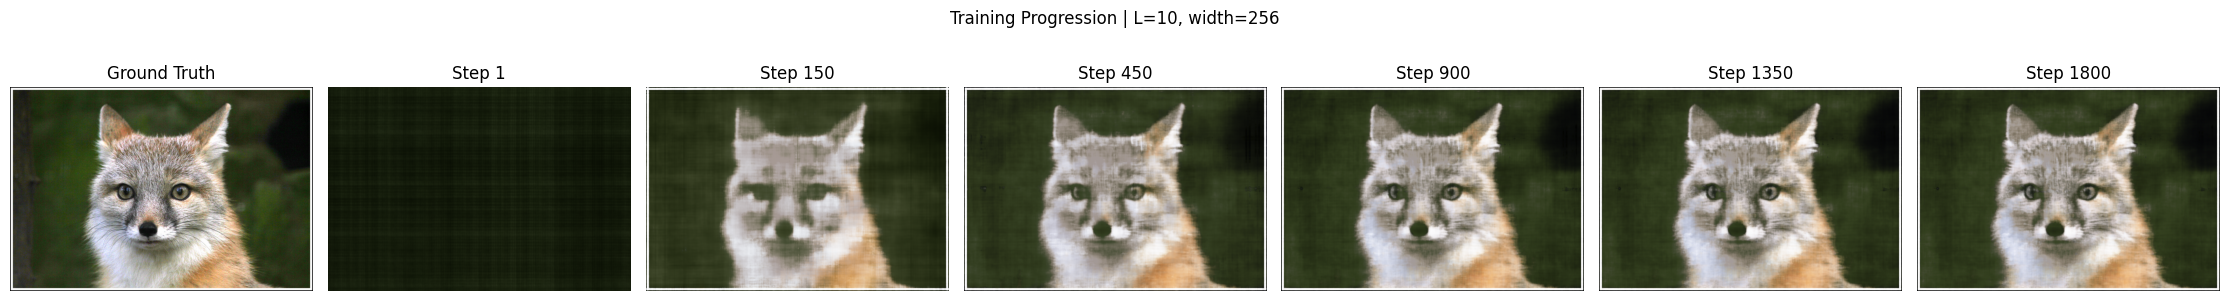

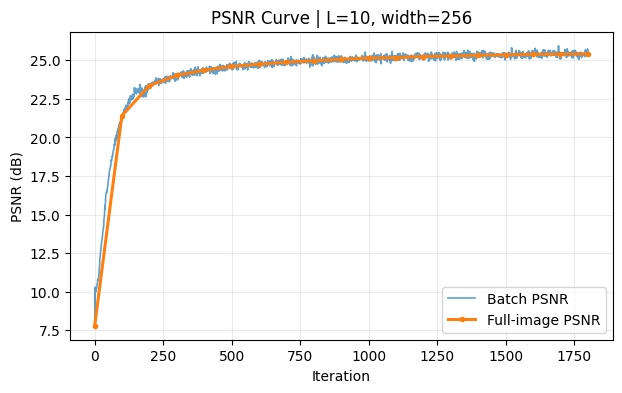

Saved baseline outputs to: images\output\part1_neural_field


In [21]:
FAST_DEV_RUN = False

baseline_steps = 300 if FAST_DEV_RUN else 1800
baseline_batch = 2048 if FAST_DEV_RUN else 8000

baseline_result = train_neural_field(
    L=10,
    width=256,
    hidden_layers=4,
    lr=1e-2,
    min_lr=4e-4,
    steps=baseline_steps,
    batch_size=baseline_batch,
    checkpoint_steps=[1, 150, 450, 900, 1350, baseline_steps],
    eval_interval=100,
    use_lr_decay=True,
    use_best_checkpoint=True,
    verbose=True,
)

show_architecture(baseline_result)

plot_progression(
    baseline_result,
    save_path=OUTPUT_DIR / "baseline_progression.png",
)
plot_psnr_curve(
    baseline_result,
    save_path=OUTPUT_DIR / "baseline_psnr_curve.png",
)

Image.fromarray((baseline_result["final_img"] * 255).astype(np.uint8)).save(
    OUTPUT_DIR / "baseline_final.png"
)
print(f"Saved baseline outputs to: {OUTPUT_DIR}")

## 2x2 Hyperparameter Grid

This cell runs 4 experiments across:

- Positional encoding frequency `L in {4, 10}`
- MLP width `width in {128, 256}`

It then visualizes final reconstructions in a 2x2 grid and reports final PSNR for each run.

Step    1/2600 | MSE: 0.102310 | PSNR(batch): 9.90 dB | LR: 0.007989
Step  100/2600 | MSE: 0.006142 | PSNR(batch): 22.12 dB | LR: 0.006941
Step  200/2600 | MSE: 0.003675 | PSNR(batch): 24.35 dB | LR: 0.006023
Step  300/2600 | MSE: 0.002850 | PSNR(batch): 25.45 dB | LR: 0.005226
Step  400/2600 | MSE: 0.002838 | PSNR(batch): 25.47 dB | LR: 0.004534
Step  500/2600 | MSE: 0.002840 | PSNR(batch): 25.47 dB | LR: 0.003934
Step  600/2600 | MSE: 0.002611 | PSNR(batch): 25.83 dB | LR: 0.003414
Step  700/2600 | MSE: 0.002401 | PSNR(batch): 26.20 dB | LR: 0.002962
Step  800/2600 | MSE: 0.002486 | PSNR(batch): 26.05 dB | LR: 0.002570
Step  900/2600 | MSE: 0.002268 | PSNR(batch): 26.44 dB | LR: 0.002230
Step 1000/2600 | MSE: 0.002141 | PSNR(batch): 26.69 dB | LR: 0.001935
Step 1100/2600 | MSE: 0.002214 | PSNR(batch): 26.55 dB | LR: 0.001679
Step 1200/2600 | MSE: 0.002173 | PSNR(batch): 26.63 dB | LR: 0.001457
Step 1300/2600 | MSE: 0.002133 | PSNR(batch): 26.71 dB | LR: 0.001264
Step 1400/2600 | MSE:

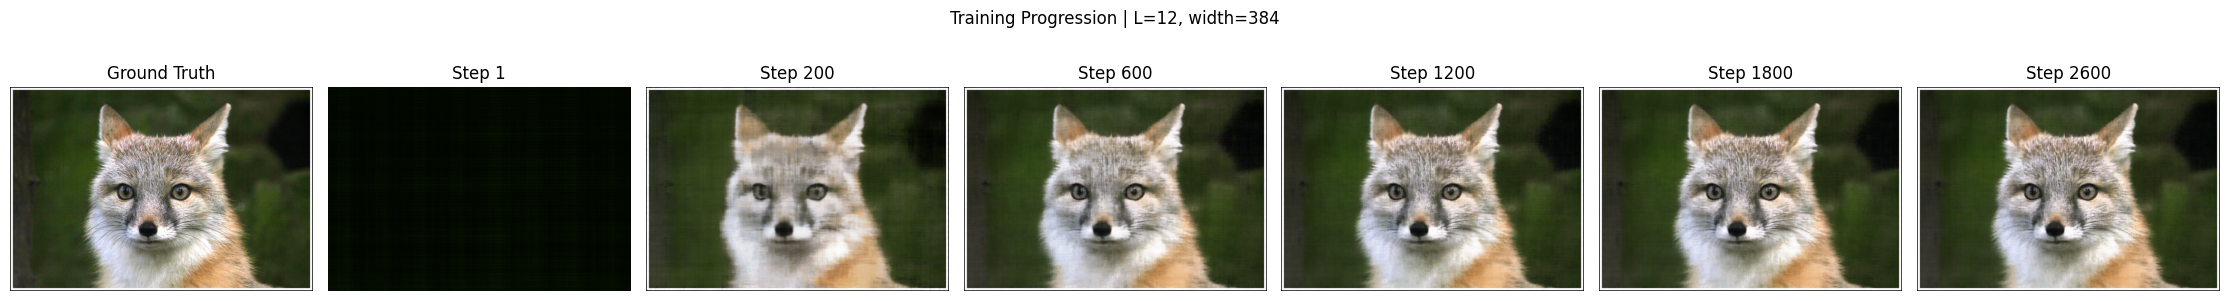

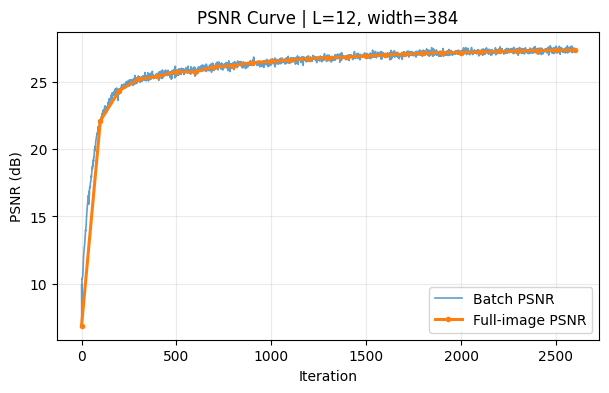

Baseline final PSNR: 25.43 dB
HQ final PSNR: 27.37 dB
Saved HQ outputs to: images\output\part1_neural_field


In [24]:
hq_steps = 350 if FAST_DEV_RUN else 2600
hq_batch = 2048 if FAST_DEV_RUN else 10000

hq_result = train_neural_field(
    L=12,
    width=384,
    hidden_layers=5,
    lr=8e-3,
    min_lr=2e-4,
    steps=hq_steps,
    batch_size=hq_batch,
    checkpoint_steps=[1, 200, 600, 1200, 1800, hq_steps],
    eval_interval=100,
    use_lr_decay=True,
    use_best_checkpoint=True,
    verbose=True,
)

show_architecture(hq_result)
plot_progression(hq_result, save_path=OUTPUT_DIR / "hq_progression.png")
plot_psnr_curve(hq_result, save_path=OUTPUT_DIR / "hq_psnr_curve.png")

Image.fromarray((hq_result["final_img"] * 255).astype(np.uint8)).save(
    OUTPUT_DIR / "hq_final.png"
)

if "baseline_result" in globals():
    print(f"Baseline final PSNR: {baseline_result['final_psnr']:.2f} dB")
print(f"HQ final PSNR: {hq_result['final_psnr']:.2f} dB")
print(f"Saved HQ outputs to: {OUTPUT_DIR}")

## High-Quality Reconstruction Run

This run is tuned to improve visual sharpness and PSNR using:

- Larger model capacity
- Learning-rate decay to a lower final LR
- Periodic full-image PSNR evaluation
- Automatic restore of the best checkpoint

`FAST_DEV_RUN=False` uses a stronger setup (including batch size 10k).


Running config: L=4, width=128
Step    1/1000 | MSE: 0.104248 | PSNR(batch): 9.82 dB | LR: 0.009972
Step  100/1000 | MSE: 0.015998 | PSNR(batch): 17.96 dB | LR: 0.007546
Step  200/1000 | MSE: 0.009020 | PSNR(batch): 20.45 dB | LR: 0.005694
Step  300/1000 | MSE: 0.005677 | PSNR(batch): 22.46 dB | LR: 0.004296
Step  400/1000 | MSE: 0.004475 | PSNR(batch): 23.49 dB | LR: 0.003242
Step  500/1000 | MSE: 0.004343 | PSNR(batch): 23.62 dB | LR: 0.002446
Step  600/1000 | MSE: 0.004081 | PSNR(batch): 23.89 dB | LR: 0.001846
Step  700/1000 | MSE: 0.003971 | PSNR(batch): 24.01 dB | LR: 0.001393
Step  800/1000 | MSE: 0.003969 | PSNR(batch): 24.01 dB | LR: 0.001051
Step  900/1000 | MSE: 0.003637 | PSNR(batch): 24.39 dB | LR: 0.000793
Step 1000/1000 | MSE: 0.003774 | PSNR(batch): 24.23 dB | LR: 0.000598

Running config: L=4, width=256
Step    1/1000 | MSE: 0.103496 | PSNR(batch): 9.85 dB | LR: 0.009972
Step  100/1000 | MSE: 0.016970 | PSNR(batch): 17.70 dB | LR: 0.007546
Step  200/1000 | MSE: 0.0109

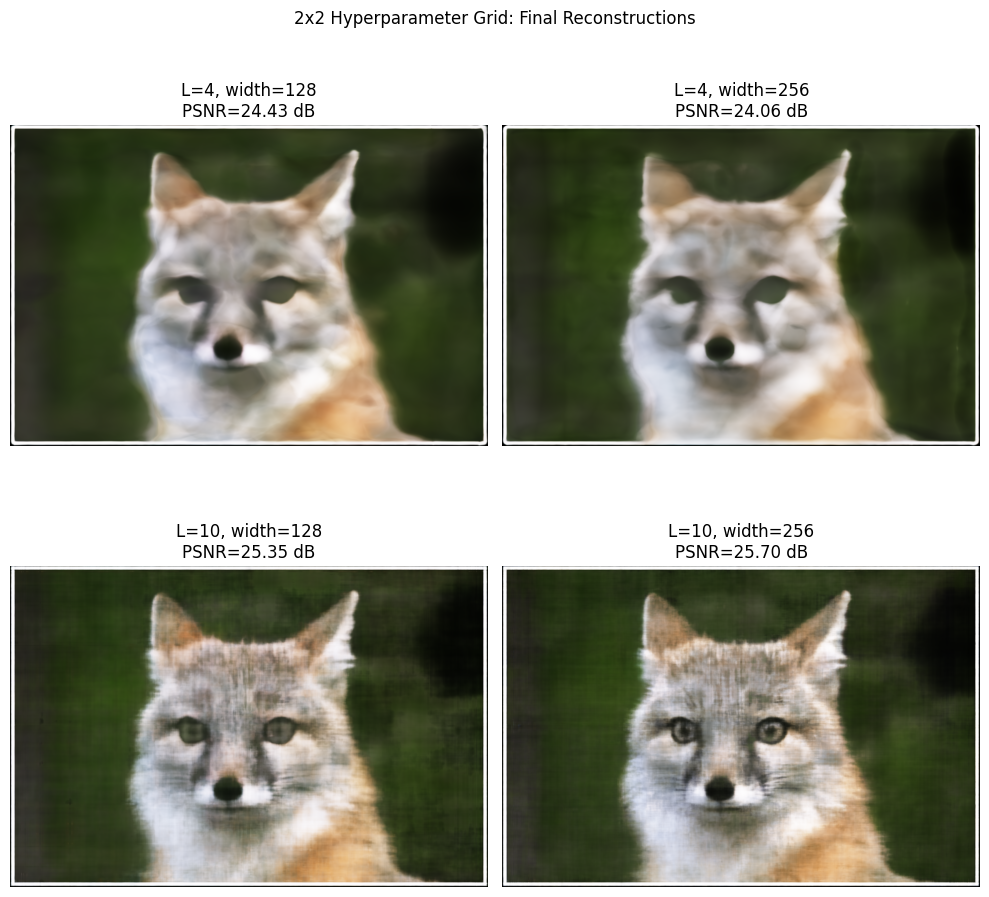


Final PSNR table
L=4, width=128: 24.43 dB
L=4, width=256: 24.06 dB
L=10, width=128: 25.35 dB
L=10, width=256: 25.70 dB


In [25]:
grid_steps = 220 if FAST_DEV_RUN else 1000
grid_batch = 2048 if FAST_DEV_RUN else 6000
L_choices = [4, 10]
W_choices = [128, 256]

results_grid = {}
for L in L_choices:
    for width in W_choices:
        print(f"\nRunning config: L={L}, width={width}")
        res = train_neural_field(
            L=L,
            width=width,
            hidden_layers=4,
            lr=1e-2,
            min_lr=6e-4,
            steps=grid_steps,
            batch_size=grid_batch,
            eval_interval=120,
            use_lr_decay=True,
            use_best_checkpoint=True,
            verbose=True,
        )
        results_grid[(L, width)] = res

fig, axes = plt.subplots(len(L_choices), len(W_choices), figsize=(10, 10))
for i, L in enumerate(L_choices):
    for j, width in enumerate(W_choices):
        ax = axes[i, j]
        res = results_grid[(L, width)]
        ax.imshow(res["final_img"])
        ax.set_title(f"L={L}, width={width}\nPSNR={res['final_psnr']:.2f} dB")
        ax.axis("off")

plt.suptitle("2x2 Hyperparameter Grid: Final Reconstructions")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "grid_2x2_results.png", dpi=180, bbox_inches="tight")
plt.show()

print("\nFinal PSNR table")
for L in L_choices:
    for width in W_choices:
        print(f"L={L}, width={width}: {results_grid[(L, width)]['final_psnr']:.2f} dB")

In [32]:
# Export metrics for HTML report generation
import json

report_data = {
    "baseline": {
        "psnr": float(baseline_result["final_psnr"]),
        "mse": float(baseline_result["final_mse"]),
        "config": baseline_result["config"],
    },
    "hq": {
        "psnr": float(hq_result["final_psnr"]),
        "mse": float(hq_result["final_mse"]),
        "best_psnr": float(hq_result["best_psnr"]),
        "best_step": int(hq_result["best_step"]),
        "config": hq_result["config"],
    },
    "grid": [],
}

for (L, width), res in sorted(results_grid.items()):
    report_data["grid"].append(
        {
            "L": int(L),
            "width": int(width),
            "psnr": float(res["final_psnr"]),
            "mse": float(res["final_mse"]),
        }
    )

metrics_path = OUTPUT_DIR / "report_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(report_data, f, indent=2)

print(f"Saved report metrics to: {metrics_path}")

Saved report metrics to: images\output\part1_neural_field\report_metrics.json
